# Exploratory Data Analysis

This notebook explores the San Diego police stops dataset (2014-2017) merged with the Social Vulnerability Index (SVI) by police service area. The goal is to understand patterns in search rates across demographics, stop context, and neighborhood vulnerability before building a predictive model.

**Prerequisites:** Run `1_data_processing.ipynb` first. This notebook reads from the intermediate merged dataset produced during data wrangling.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from paths import *

Load the merged SOPP-SVI dataset and parse temporal features for use in the analysis.

In [2]:
df = pd.read_csv(INT_DATA_PATH / "sopp_svi_merged.csv")
df["search_conducted"] = (df["search_conducted"] == True) | (df["search_conducted"] == "True")
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["hour"] = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce").dt.hour
df["is_night"] = (df["hour"] >= 18) | (df["hour"] < 6)

print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Dataset: 383,027 rows, 29 columns
Date range: 2014-01-01 to 2017-03-31


## 2. Target Variable

Our target is `search_conducted`, a binary variable indicating whether an officer searched the person during a stop. The overall search rate is low, meaning the classes are imbalanced. This will inform our choice of model and evaluation metric later on.

In [3]:
n_total = len(df)
n_searched = int(df["search_conducted"].sum())
overall_rate = df["search_conducted"].mean() * 100

print(f"Total stops: {n_total:,}")
print(f"Stops with a search: {n_searched:,}")
print(f"Overall search rate: {overall_rate:.2f}%")
print()
yr = df.groupby("year")["search_conducted"].agg(["mean", "sum"])
yr["rate"] = (yr["mean"] * 100).round(2).astype(str) + "%"
yr = yr.rename(columns={"sum": "searches"})
print("Search rate by year:")
print(yr[["rate", "searches"]].to_string())

Total stops: 383,027
Stops with a search: 16,288
Overall search rate: 4.25%

Search rate by year:
         rate  searches
year                   
2014.0  4.92%      6855
2015.0  3.77%      4251
2016.0  3.81%      3914
2017.0  4.38%      1234


## 3. Search Rate by Neighborhood Vulnerability (SVI)

The Social Vulnerability Index measures how vulnerable a neighborhood is based on socioeconomic factors, housing composition, and demographics. We split SVI into quartiles (Q1 = least vulnerable, Q4 = most vulnerable) and compare search rates.

If search rates differ across SVI quartiles, it suggests that where a stop happens is associated with the likelihood of a search.

In [4]:
overall_rate = df["search_conducted"].mean()
tmp = df.dropna(subset=["svi_rpl_themes", "search_conducted"]).copy()
tmp["search_01"] = tmp["search_conducted"].astype(int)
tmp["svi_quartile"] = pd.qcut(tmp["svi_rpl_themes"], 4, labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])

svi_summary = tmp.groupby("svi_quartile", observed=False).agg(
    n=("search_01", "size"),
    search_rate=("search_01", "mean")
).reset_index()
svi_summary["search_rate_pct"] = (svi_summary["search_rate"] * 100).round(2)
svi_summary["ratio_to_baseline"] = (svi_summary["search_rate"] / overall_rate).round(2)

print("Search rate by SVI quartile:")
print(svi_summary[["svi_quartile", "n", "search_rate_pct", "ratio_to_baseline"]].to_string(index=False))

Search rate by SVI quartile:
svi_quartile      n  search_rate_pct  ratio_to_baseline
    Q1 (low) 100062             2.89               0.68
          Q2 106168             2.91               0.69
          Q3  78279             5.54               1.30
   Q4 (high)  86891             6.50               1.53


### Ratio to overall average

Each bar shows how a quartile's search rate compares to the dataset-wide average. A value of 1.0 means the quartile matches the average; values above 1.0 indicate higher-than-average search rates.

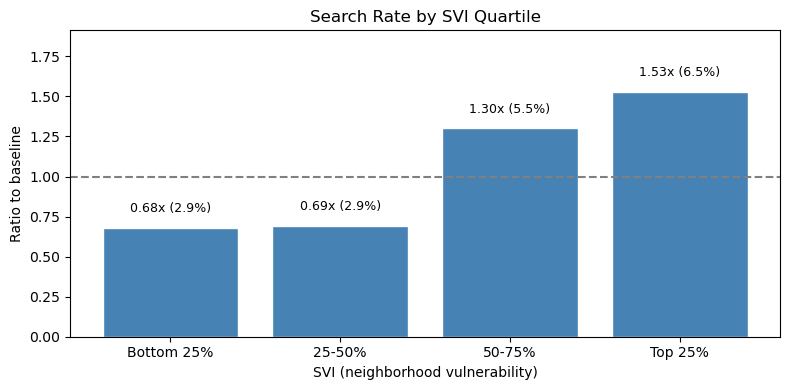

In [5]:
svi_labels = {"Q1 (low)": "Bottom 25%", "Q2": "25-50%", "Q3": "50-75%", "Q4 (high)": "Top 25%"}
svi_summary["x_label"] = svi_summary["svi_quartile"].astype(str).map(svi_labels)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(svi_summary["x_label"], svi_summary["ratio_to_baseline"], color="steelblue", edgecolor="white")
ax.axhline(1.0, color="gray", linestyle="--", label="Baseline (overall avg)")
ax.set_title("Search Rate by SVI Quartile")
ax.set_ylabel("Ratio to baseline")
ax.set_xlabel("SVI (neighborhood vulnerability)")
ymax = svi_summary["ratio_to_baseline"].max()
ax.set_ylim(top=ymax * 1.25)
bbox_props = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor="none")
for bar, ratio, pct in zip(bars, svi_summary["ratio_to_baseline"], svi_summary["search_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
            f"{ratio:.2f}x ({pct:.1f}%)", ha="center", va="bottom", fontsize=9, bbox=bbox_props)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Analysis

The search rate increases steadily with neighborhood vulnerability. Stops in the most vulnerable quartile (Q4) are searched at roughly 2.3x the overall average, while stops in the least vulnerable quartile (Q1) fall well below the baseline. This suggests that neighborhood context plays a meaningful role in whether a search occurs.

### Deviation from mean

Each bar shows how many percentage points above or below the overall average each quartile falls. Coral bars are above average, blue bars are below.

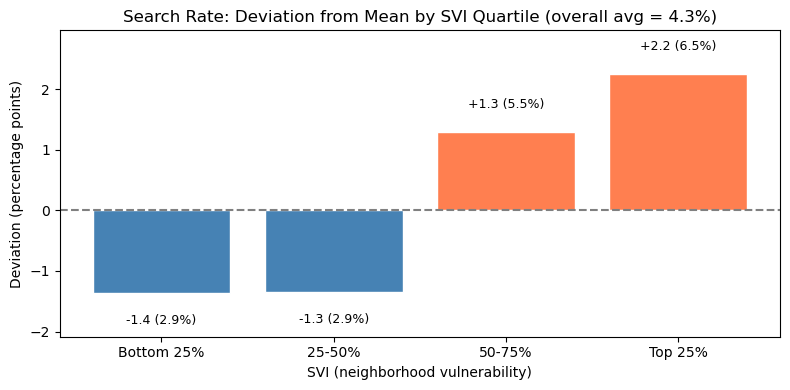

In [6]:
overall_rate_pct = overall_rate * 100
svi_summary["deviation_pp"] = svi_summary["search_rate_pct"] - overall_rate_pct

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor("none")
ax.patch.set_facecolor("none")
vals = svi_summary["deviation_pp"]
colors = ["steelblue" if v < 0 else "coral" for v in vals]
bars = ax.bar(svi_summary["x_label"], vals, color=colors, edgecolor="white")
ax.axhline(0, color="gray", linestyle="--", label="Overall mean")
ax.set_title(f"Search Rate: Deviation from Mean by SVI Quartile (overall avg = {overall_rate_pct:.1f}%)")
ax.set_ylabel("Deviation (percentage points)")
ax.set_xlabel("SVI (neighborhood vulnerability)")
ax.margins(y=0.2)
bbox_props = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor="none")
for bar, dev, pct in zip(bars, svi_summary["deviation_pp"], svi_summary["search_rate_pct"]):
    y = bar.get_height()
    va = "bottom" if y >= 0 else "top"
    offset = 0.35 if y >= 0 else -0.35
    ax.text(bar.get_x() + bar.get_width()/2, y + offset,
            f"{dev:+.1f} ({pct:.1f}%)", ha="center", va=va, fontsize=9, bbox=bbox_props)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Analysis

The deviation plot confirms a clear gradient. The bottom two SVI quartiles fall below the overall mean, while the top two are above it. The gap between Q1 and Q4 is several percentage points, which is substantial given the low base rate of searches overall.

## 4. Search Rate by Race across SVI Quartiles

Here we look at whether racial disparities in search rates hold across neighborhoods with different vulnerability levels. If the lines are roughly parallel, racial gaps persist regardless of neighborhood. If they converge or diverge, the relationship between race and search likelihood depends on where the stop happens.

In [7]:
race_summary = df.groupby("subject_race").agg(
    n=("search_conducted", "size"),
    search_rate=("search_conducted", lambda x: x.eq(True).mean())
).reset_index()
race_summary["search_rate_pct"] = (race_summary["search_rate"] * 100).round(2)
race_summary = race_summary.sort_values("search_rate", ascending=False)

print("Search rate by race:")
print(race_summary[["subject_race", "n", "search_rate_pct"]].to_string(index=False))

Search rate by race:
          subject_race      n  search_rate_pct
                 black  42705             9.07
              hispanic 117083             5.55
asian/pacific islander  32541             2.80
                 white 162226             2.78
                 other  27238             1.66


### Cross-tabulation: Race x SVI Quartile

The table below shows the search rate for each combination of race and SVI quartile, giving the raw numbers behind the line plot that follows.

In [8]:
top_races = tmp["subject_race"].value_counts().head(5).index.tolist()
tmp_race = tmp[tmp["subject_race"].isin(top_races)]
race_svi = tmp_race.groupby(["subject_race", "svi_quartile"], observed=False)["search_01"].mean().unstack()
race_svi_pct = (race_svi * 100).round(2)

print("Search rate (%) by Race x SVI quartile:")
print(race_svi_pct.to_string())

Search rate (%) by Race x SVI quartile:
svi_quartile            Q1 (low)    Q2    Q3  Q4 (high)
subject_race                                           
asian/pacific islander      1.99  1.56  4.67       5.58
black                       5.09  5.82  9.37      13.16
hispanic                    4.50  4.59  7.99       5.36
other                       1.27  1.42  1.85       3.49
white                       2.65  2.32  3.23       4.83


### Line plot

Each line represents a racial group. The x-axis moves from least vulnerable (Q1) to most vulnerable (Q4) neighborhoods. This reveals whether the racial gap in search rates widens, narrows, or stays constant as neighborhood vulnerability increases.

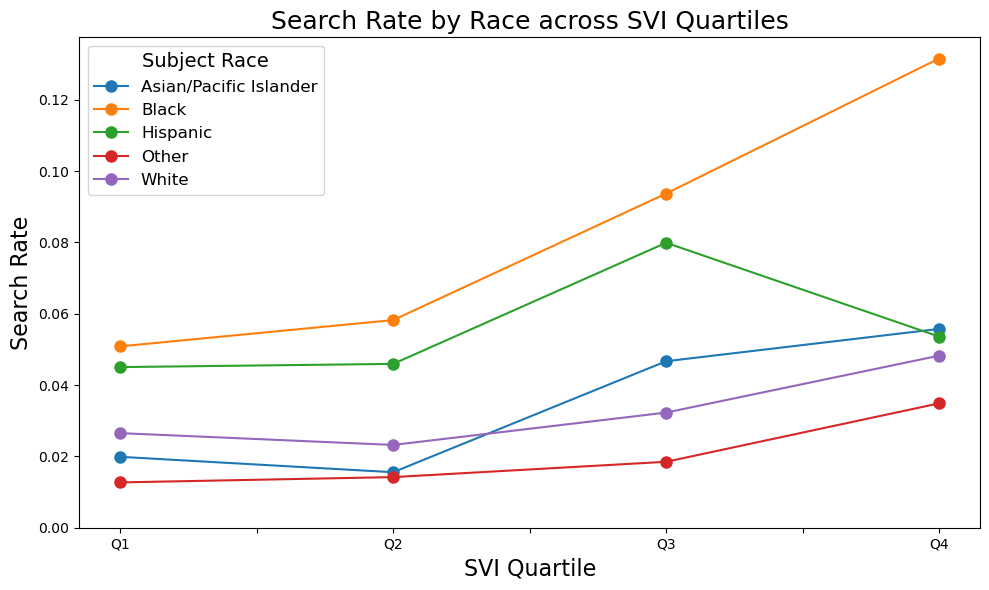

In [9]:
df_cc = df.dropna(subset=["svi_rpl_themes", "subject_race", "search_conducted"]).copy()
df_cc["svi_quartile"] = pd.qcut(df_cc["svi_rpl_themes"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
pivot_race_svi = df_cc.pivot_table(
    values="search_conducted",
    index="svi_quartile",
    columns="subject_race",
    aggfunc="mean",
    observed=False,
)
race_labels_line = {
    "asian/pacific islander": "Asian/Pacific Islander",
    "black": "Black",
    "hispanic": "Hispanic",
    "other": "Other",
    "white": "White",
}
pivot_race_svi = pivot_race_svi.rename(columns=race_labels_line)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("none")
ax.patch.set_facecolor("none")
pivot_race_svi.plot(ax=ax, marker="o", markersize=8)
ax.set_xlabel("SVI Quartile", fontsize=16)
ax.set_ylabel("Search Rate", fontsize=16)
ax.set_title("Search Rate by Race across SVI Quartiles", fontsize=18)
ax.tick_params(axis="both", labelsize=10)
ax.legend(title="Subject Race", loc="upper left", fontsize=12, title_fontsize=14)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

#### Analysis

Black subjects have the highest search rate in every SVI quartile, and the gap between Black and other racial groups tends to widen in more vulnerable neighborhoods. White and Asian/Pacific Islander subjects are searched at consistently lower rates. This indicates that racial disparities in search rates are not explained away by neighborhood vulnerability alone.

## 5. Search Rate by Reason for Stop

Not all stops carry the same likelihood of a search. A routine traffic violation rarely leads to a search, while a stop based on a dispatch call or suspect information is more targeted. We group the reasons into the six most common categories plus an "Other" bucket and compare search rates.

Each bar annotation shows the search rate and what fraction of all stops that reason accounts for.

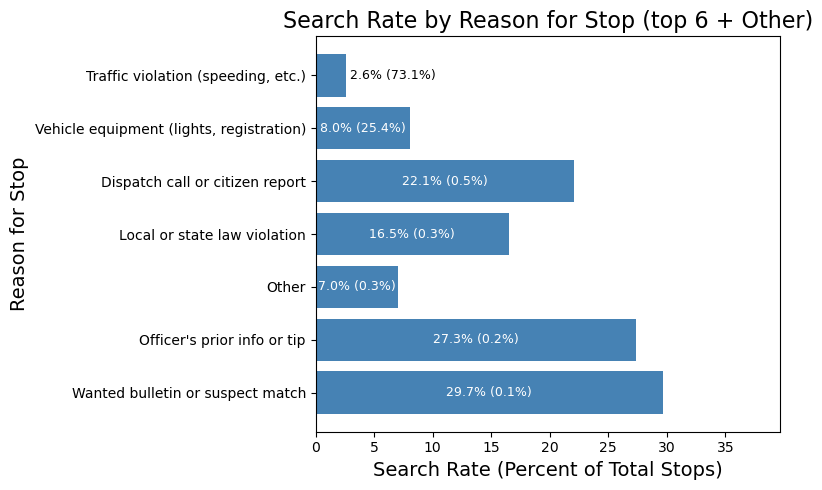

In [10]:
K = 6
top_reasons = df["reason_for_stop"].value_counts(dropna=True).head(K).index.tolist()
reason_grp = df["reason_for_stop"].where(df["reason_for_stop"].isin(top_reasons), "Other")
reason_df = df.assign(reason_grp=reason_grp).dropna(subset=["reason_grp"])
total_stops = len(reason_df)
reason_summary = reason_df.groupby("reason_grp").agg(
    n=("search_conducted", "size"),
    search_rate=("search_conducted", lambda x: x.eq(True).mean() * 100),
).reset_index()
reason_summary["pct_of_stops"] = reason_summary["n"] / total_stops * 100
reason_summary = reason_summary.sort_values("n", ascending=True).reset_index(drop=True)

reason_labels = {
    "Moving Violation": "Traffic violation (speeding, etc.)",
    "Equipment Violation": "Vehicle equipment (lights, registration)",
    "Radio Call/Citizen Contact": "Dispatch call or citizen report",
    "Muni, County, H&S Code": "Local or state law violation",
    "Personal Knowledge/Informant": "Officer's prior info or tip",
    "Suspect Info (I.S., Bulletin, Log)": "Wanted bulletin or suspect match",
    "No Cause Specified on a Card": "Reason not recorded",
    "Personal Observ/Knowledge": "Officer's direct observation",
    "Other": "Other",
}
reason_summary["reason_label"] = reason_summary["reason_grp"].map(
    lambda x: reason_labels.get(x, x)
)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("none")
ax.patch.set_facecolor("none")
bars = ax.barh(reason_summary["reason_label"], reason_summary["search_rate"], color="steelblue")
for bar, reason, sr, pct in zip(bars, reason_summary["reason_grp"],
                                 reason_summary["search_rate"], reason_summary["pct_of_stops"]):
    label = f"{sr:.1f}% ({pct:.1f}%)"
    y_center = bar.get_y() + bar.get_height() / 2
    if reason == "Moving Violation":
        ax.text(bar.get_width() + 0.3, y_center, label, va="center", ha="left", fontsize=9)
    else:
        ax.text(bar.get_width() / 2, y_center, label, va="center", ha="center",
                fontsize=9, color="white")
ax.set_xlabel("Search Rate (Percent of Total Stops)", fontsize=14)
ax.set_ylabel("Reason for Stop", fontsize=14)
ax.set_title("Search Rate by Reason for Stop (top 6 + Other)", fontsize=16)
ax.set_xlim(0, max(reason_summary["search_rate"].max() * 1.15,
                   reason_summary["search_rate"].max() + 10))
plt.tight_layout()
plt.show()

#### Analysis

Stops initiated by dispatch calls or suspect information have much higher search rates than routine traffic and equipment stops, even though traffic stops make up the majority of all encounters. This tells us that the reason for the stop is one of the strongest predictors of whether a search will happen, and it should be an important feature in the model.